# Procesos ETL
## Transformación

## Paso 1.
Importar Librerias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os
from infrastructure.clients.mongo_client import MongoDBClient
from infrastructure.repositories.generic_repository import GenericRepository
from infrastructure.extractors.mongo_extractor import MongoExtractor

## Paso 2.
Rutas de los insumos

In [2]:
mongo_client = MongoDBClient("mongodb://localhost:27017", "airbnb")
repo = GenericRepository(mongo_client)
df_listings = MongoExtractor(repo).extract("listings")
# df_reviews = MongoExtractor(repo).extract("reviews")
# df_calendar = MongoExtractor(repo).extract("calendar")


2025-10-09 21:23:35.758 | INFO     | infrastructure.clients.mongo_client:__init__:14 - Inicializando cliente MongoDB para: airbnb
2025-10-09 21:23:35.761 | INFO     | infrastructure.repositories.generic_repository:__init__:10 - Repository inicializado correctamente.
2025-10-09 21:23:35.762 | INFO     | infrastructure.repositories.generic_repository:read_collection:23 - 🔍 Leyendo colección 'listings'...
2025-10-09 21:23:35.763 | WARNING  | infrastructure.clients.mongo_client:get_collection:35 - ⚠️ Base de datos no conectada, intentando reconectar...
2025-10-09 21:23:35.763 | INFO     | infrastructure.clients.mongo_client:connect:19 - Intentando conectar a MongoDB → mongodb://localhost:27017/airbnb
2025-10-09 21:23:35.897 | SUCCESS  | infrastructure.clients.mongo_client:connect:23 - ✅ Conexión exitosa a MongoDB → airbnb
2025-10-09 21:23:35.898 | INFO     | infrastructure.clients.mongo_client:get_collection:38 - 📂 Accediendo a colección: listings
2025-10-09 21:23:36.746 | SUCCESS  | infra

## Exploración

## Previsualización de los datos

In [ ]:
print(df_listings.head())

                        _id  listing_id       id       date  reviewer_id  \
0  68b7a7c3c2d35d8ddd66e367       44616   706908 2011-11-09       634733   
1  68b7a7c3c2d35d8ddd66e368       44616  2006160 2012-08-16      3087087   
2  68b7a7c3c2d35d8ddd66e369       44616  3174954 2012-12-28      3234920   
3  68b7a7c3c2d35d8ddd66e36a       44616  3271579 2013-01-04      2199822   
4  68b7a7c3c2d35d8ddd66e36b       44616  3841065 2013-03-19      2423825   

      reviewer_name                                           comments  
0           Lindsay  Forget staying in a hotel. Stay at condesa hau...  
1            Samuel  Fantastic location, great place, friendly host...  
2              Anna  I would highly recommend Condesa Haus for anyo...  
3  Shelley And Pall             Great stay. Thanks. Highly recommend.   
4          Leonardo  This was not a very good experience I am afrai...  


## Estructura Datasets

In [3]:
df_listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26067 entries, 0 to 26066
Data columns (total 77 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   _id                                           26067 non-null  object        
 1   id                                            26067 non-null  int64         
 2   listing_url                                   26067 non-null  object        
 3   scrape_id                                     26067 non-null  int64         
 4   last_scraped                                  26067 non-null  datetime64[ns]
 5   source                                        26067 non-null  object        
 6   name                                          26067 non-null  object        
 7   description                                   25300 non-null  object        
 8   neighborhood_overview                         14391 non-null  obje

# Detección y manejo de valores Nulos

## Cantidad de valores nulos por columna

In [10]:
df_listings.isnull().sum()
df_listings.isna().sum()

_id                               0
id                                0
listing_url                       0
scrape_id                         0
last_scraped                      0
                               ... 
review_scores_checkin          3262
review_scores_communication    3262
review_scores_location         3262
review_scores_value            3262
reviews_per_month              3261
Length: 77, dtype: int64

## Visualización gráfica de valores nulos

/var/folders/p2/xfh16h8x59n5n_k7qs00b5vw0000gp/T/ipykernel_19507/2090991667.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=null_percent.index, y=null_percent.values, palette="viridis")


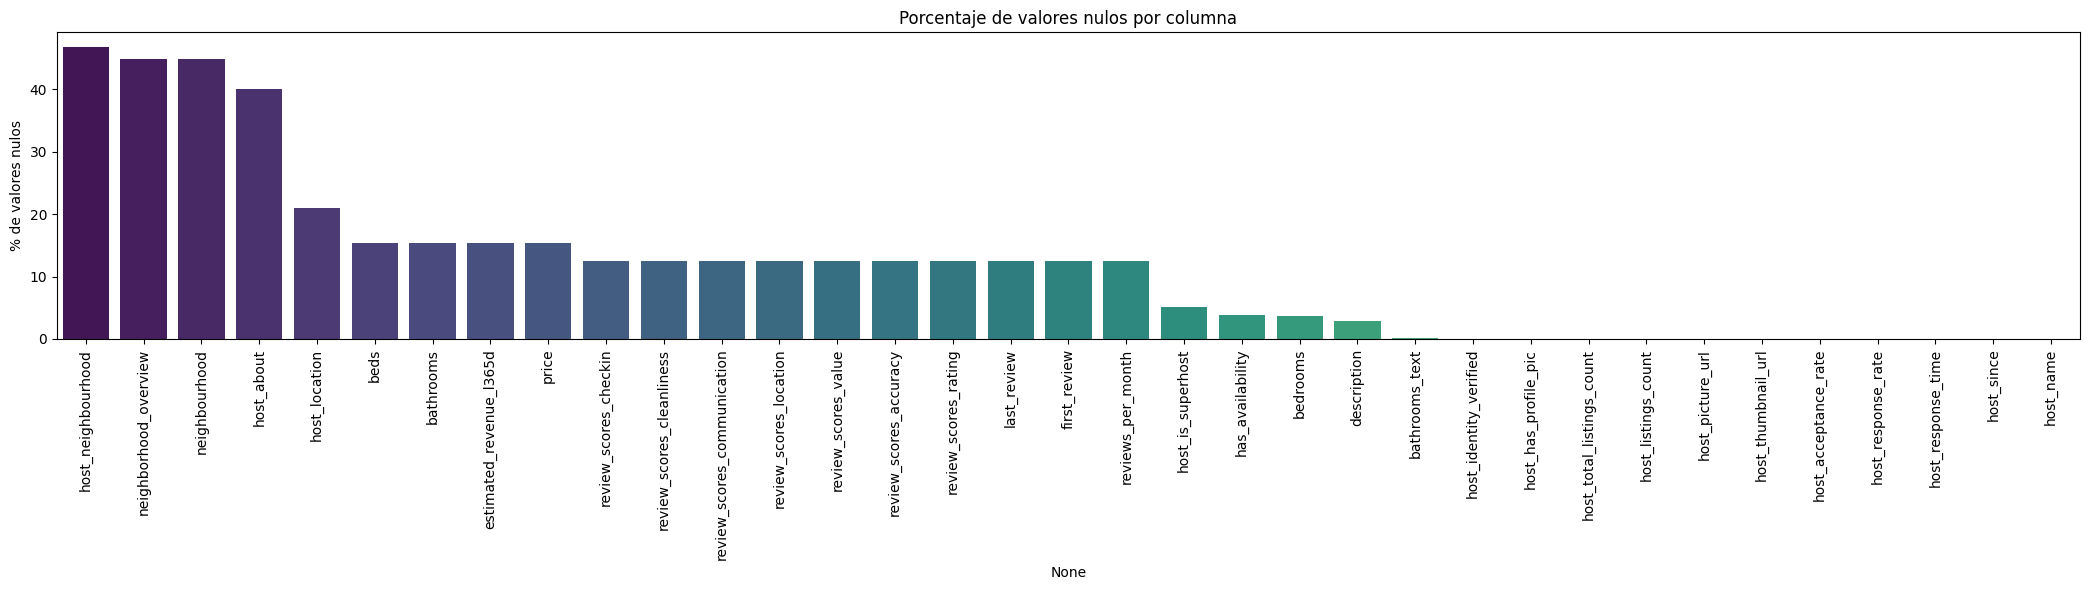

In [16]:
null_percent = df_listings.isna().mean() * 100
null_percent = null_percent[null_percent > 0].sort_values(ascending=False)

# Escala automática según cantidad de columnas
num_cols = len(null_percent)
plt.figure(figsize=(max(12, num_cols * 0.6), 6))

sns.barplot(x=null_percent.index, y=null_percent.values, palette="viridis")
plt.xticks(rotation=90, ha='center')
plt.ylabel('% de valores nulos')
plt.title('Porcentaje de valores nulos por columna')
plt.tight_layout()
plt.show()

## Eliminación de filas con valores nulos

In [36]:
df_popu_c = df_popu_c.dropna(subset=['total'])

## Eliminación de filas o columnas con muchos valores nulos

In [39]:
ts = 0.5
df_meta_c = df_meta.dropna(thresh=int(ts * df_meta.shape[0]), axis=1)

### Imputación de valores faltantes en 'region' con 'Sin region'

In [41]:
df_meta_c.loc[:, 'Region'] = df_meta_c['Region'].fillna('Sin region')

# Eliminar duplicados

## Identificar Duplicados

In [20]:
for col in df_listings.columns:
    if df_listings[col].apply(lambda x: isinstance(x, (list, dict, set))).any():
        print(f"⚠️ Columna con datos no hashables: {col}")

⚠️ Columna con datos no hashables: host_verifications
⚠️ Columna con datos no hashables: amenities


In [22]:
# Ignorar columnas no hashables
cols_validas = [col for col in df_listings.columns if col not in ['host_verifications', 'amenities']]

# Buscar duplicados solo en columnas válidas
dupli_rows = df_listings[df_listings.duplicated(subset=cols_validas, keep=False)]

print(f"Registros duplicados: {dupli_rows.shape[0]}")



Registros duplicados: 0


# Valores Atipicos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26067 entries, 0 to 26066
Data columns (total 77 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   _id                                           26067 non-null  object        
 1   id                                            26067 non-null  int64         
 2   listing_url                                   26067 non-null  object        
 3   scrape_id                                     26067 non-null  int64         
 4   last_scraped                                  26067 non-null  datetime64[ns]
 5   source                                        26067 non-null  object        
 6   name                                          26067 non-null  object        
 7   description                                   25300 non-null  object        
 8   neighborhood_overview                         14391 non-null  obje

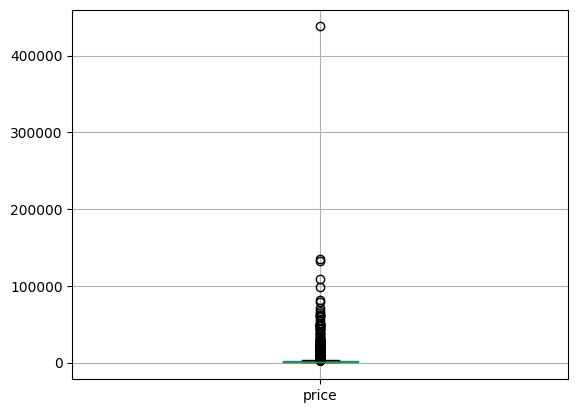

In [35]:
df_listings.info()

# Limpieza del campo 'price'
df_listings['price'] = (
    df_listings['price']
    .astype(str)              # asegúrate de que todo sea string
    .str.replace(r'[\$,€]', '', regex=True)  # elimina símbolos de moneda
    .str.replace(',', '', regex=False)       # elimina comas de miles
    .str.strip()                             # elimina espacios
)

# Convertir a número (los que no se puedan convertir serán NaN)
df_listings['price'] = pd.to_numeric(df_listings['price'], errors='coerce')

# Verifica que se haya convertido correctamente
print(df_listings['price'].describe())

df_listings.boxplot(column='price')
plt.show()